In [31]:
import os, json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 67
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch : {torch.__version__}")
print(f"Device  : {DEVICE}")
print(f"Seed    : {SEED}")

os.makedirs("artifacts/figures", exist_ok=True)

PyTorch : 2.10.0+cpu
Device  : cpu
Seed    : 67


In [32]:
def compute_metrics(y_true, y_pred):
    """MAE, RMSE, MAPE (%)."""
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = np.abs(y_true) > 1e-8
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() else np.nan
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

def print_metrics(label, m):
    print(f"{label}:  MAE={m['MAE']:.4f}  RMSE={m['RMSE']:.4f}  MAPE={m['MAPE']:.2f}%")

## 2. Данные и первичный анализ

In [34]:
df = pd.read_csv("S12-hw-dataset.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Размер датасета       : {df.shape}")
print(f"Столбцы               : {list(df.columns)}")
print(f"Диапазон дат          : {df['date'].min().date()} — {df['date'].max().date()}")
print(f"Число наблюдений      : {len(df)}")
print(f"\nПропуски по столбцам:\n{df.isnull().sum()}")
print(f"\nОписательная статистика:")
df.describe()

Размер датасета       : (4320, 2)
Столбцы               : ['date', 'target']
Диапазон дат          : 2025-01-01 — 2025-06-29
Число наблюдений      : 4320

Пропуски по столбцам:
date      0
target    0
dtype: int64

Описательная статистика:


,date,target
count,4320,4320.000000
mean,2025-03-31 23:29:59.999999744,135.605840
min,2025-01-01 00:00:00,69.100000
25%,2025-02-14 23:45:00,120.537500
50%,2025-03-31 23:30:00,135.835000
75%,2025-05-15 23:15:00,150.625000
max,2025-06-29 23:00:00,210.100000
std,NaN,21.384633


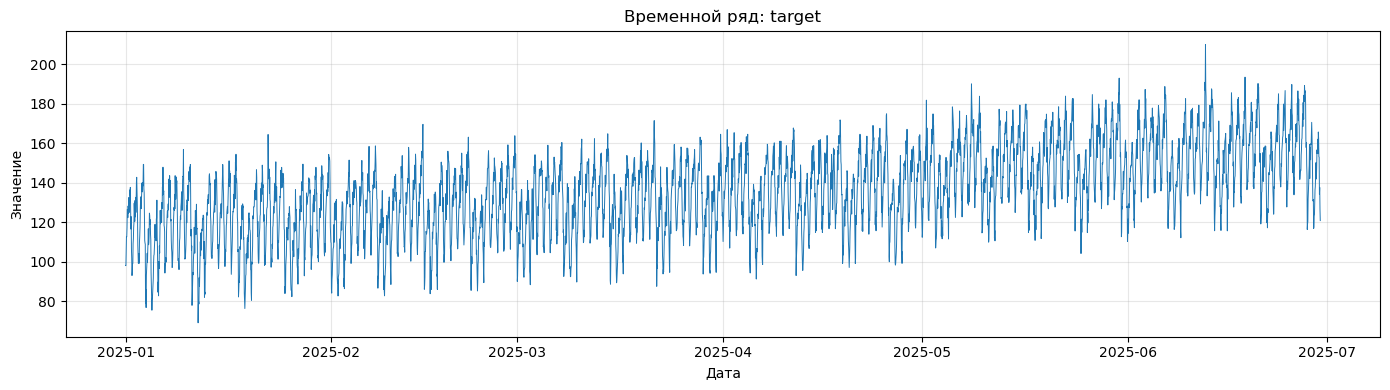

In [35]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["date"], df["target"], linewidth=0.7)
ax.set_title("Временной ряд: target")
ax.set_xlabel("Дата"); ax.set_ylabel("Значение")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("artifacts/figures/series_overview.png", dpi=150, bbox_inches="tight")
plt.show()

# Комментарий к данным

Ряд демонстрирует слабый восходящий тренд и выраженную недельную сезонность. Значимых выбросов не обнаружено.

In [37]:
# 3. split

n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df   = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()

SPLIT_SUMMARY = f"train={len(train_df)},val={len(val_df)},test={len(test_df)}"

print(f"Train : {len(train_df):>5}  | {train_df['date'].iloc[0].date()} — {train_df['date'].iloc[-1].date()}")
print(f"Val   : {len(val_df):>5}  | {val_df['date'].iloc[0].date()} — {val_df['date'].iloc[-1].date()}")
print(f"Test  : {len(test_df):>5}  | {test_df['date'].iloc[0].date()} — {test_df['date'].iloc[-1].date()}")
print(f"Split : {SPLIT_SUMMARY}")

Train :  3024  | 2025-01-01 — 2025-05-06
Val   :   648  | 2025-05-07 — 2025-06-02
Test  :   648  | 2025-06-03 — 2025-06-29
Split : train=3024,val=648,test=648


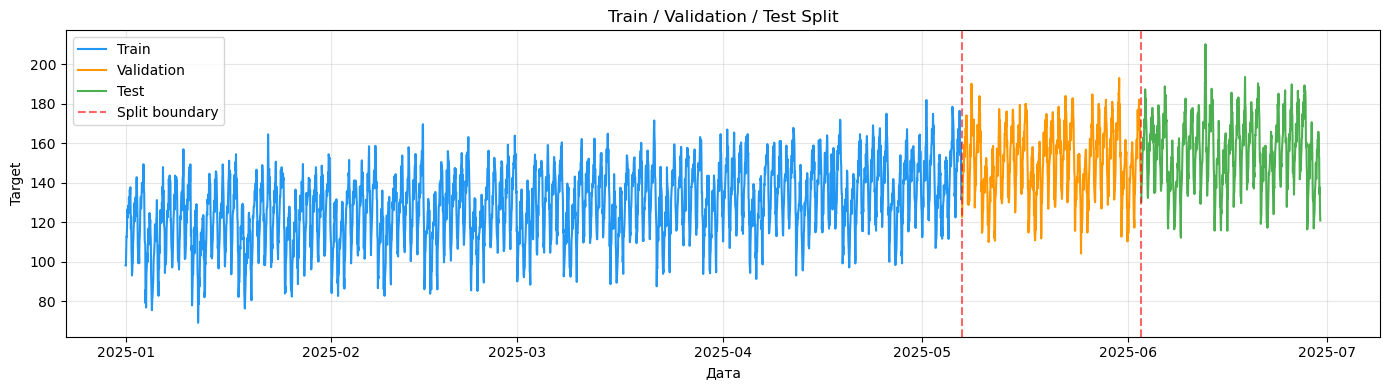

In [38]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_df["date"], train_df["target"], label="Train",      color="#2196F3")
ax.plot(val_df["date"],   val_df["target"],   label="Validation", color="#FF9800")
ax.plot(test_df["date"],  test_df["target"],  label="Test",       color="#4CAF50")
ax.axvline(train_df["date"].iloc[-1], color="red", ls="--", alpha=.6, label="Split boundary")
ax.axvline(val_df["date"].iloc[-1],   color="red", ls="--", alpha=.6)
ax.set_title("Train / Validation / Test Split")
ax.set_xlabel("Дата"); ax.set_ylabel("Target")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("artifacts/figures/series_split.png", dpi=150, bbox_inches="tight")
plt.show()

In [39]:
# 4. Признаки для baseline-моделей
df_feat = df.copy()

#  Лаговые признаки (shift гарантирует отсутствие утечки)
df_feat["lag_1"]  = df_feat["target"].shift(1)
df_feat["lag_7"]  = df_feat["target"].shift(7)
df_feat["lag_14"] = df_feat["target"].shift(14)

# Rolling-признаки (shift(1) → не включаем текущее значение)
df_feat["rolling_mean_7"] = df_feat["target"].shift(1).rolling(7).mean()
df_feat["rolling_std_7"]  = df_feat["target"].shift(1).rolling(7).std()

# Календарные признаки
df_feat["day_of_week"]  = df_feat["date"].dt.dayofweek
df_feat["month"]        = df_feat["date"].dt.month
df_feat["day_of_month"] = df_feat["date"].dt.day
df_feat["day_of_year"]  = df_feat["date"].dt.dayofyear

# Удаляем строки с NaN (первые ~14 строк из-за lag_14 / rolling)
n_before = len(df_feat)
df_feat = df_feat.dropna().reset_index(drop=True)
print(f"Удалено NaN-строк: {n_before - len(df_feat)}")
print(f"Итого строк с признаками: {len(df_feat)}")

# Пересчитываем split по датам
train_date_end = train_df["date"].iloc[-1]
val_date_end   = val_df["date"].iloc[-1]

train_feat = df_feat[df_feat["date"] <= train_date_end].copy()
val_feat   = df_feat[(df_feat["date"] > train_date_end) &
                     (df_feat["date"] <= val_date_end)].copy()
test_feat  = df_feat[df_feat["date"] > val_date_end].copy()

FEATURE_COLS = [
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_std_7",
    "day_of_week", "month", "day_of_month", "day_of_year",
]
print(f"\nПризнаки ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Train feat: {len(train_feat)} | Val feat: {len(val_feat)} | Test feat: {len(test_feat)}")

Удалено NaN-строк: 14
Итого строк с признаками: 4306

Признаки (9): ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'day_of_week', 'month', 'day_of_month', 'day_of_year']
Train feat: 3010 | Val feat: 648 | Test feat: 648


## 5. Эксперименты

### 5.1  B1 — naive-last
Прогноз = предыдущее известное значение (`lag_1`).

In [41]:
val_pred_b1  = val_feat["lag_1"].values
test_pred_b1 = test_feat["lag_1"].values

val_true_bl  = val_feat["target"].values
test_true_bl = test_feat["target"].values

m_b1_val  = compute_metrics(val_true_bl,  val_pred_b1)
m_b1_test = compute_metrics(test_true_bl, test_pred_b1)
print_metrics("B1 val ", m_b1_val)
print_metrics("B1 test", m_b1_test)

B1 val :  MAE=6.4448  RMSE=8.2010  MAPE=4.40%
B1 test:  MAE=6.3424  RMSE=8.0591  MAPE=4.15%


### 5.2  B2 — moving-average
Прогноз = скользящее среднее 7 предыдущих значений (`rolling_mean_7`, уже сдвинутое на 1).

In [43]:
val_pred_b2  = val_feat["rolling_mean_7"].values
test_pred_b2 = test_feat["rolling_mean_7"].values

m_b2_val  = compute_metrics(val_true_bl,  val_pred_b2)
m_b2_test = compute_metrics(test_true_bl, test_pred_b2)
print_metrics("B2 val ", m_b2_val)
print_metrics("B2 test", m_b2_test)

B2 val :  MAE=12.7020  RMSE=15.2176  MAPE=8.82%
B2 test:  MAE=12.7403  RMSE=15.2387  MAPE=8.55%


### 5.3  B3 — Ridge на лаговых, rolling- и календарных признаках

In [45]:
scaler_X = StandardScaler()
X_train_bl = scaler_X.fit_transform(train_feat[FEATURE_COLS])
X_val_bl   = scaler_X.transform(val_feat[FEATURE_COLS])
X_test_bl  = scaler_X.transform(test_feat[FEATURE_COLS])

y_train_bl = train_feat["target"].values

ridge = Ridge(alpha=1.0, random_state=SEED)
ridge.fit(X_train_bl, y_train_bl)

val_pred_b3  = ridge.predict(X_val_bl)
test_pred_b3 = ridge.predict(X_test_bl)

m_b3_val  = compute_metrics(val_true_bl,  val_pred_b3)
m_b3_test = compute_metrics(test_true_bl, test_pred_b3)
print_metrics("B3 val ", m_b3_val)
print_metrics("B3 test", m_b3_test)

B3 val :  MAE=6.3351  RMSE=7.9237  MAPE=4.24%
B3 test:  MAE=5.9712  RMSE=7.6454  MAPE=3.85%


### 5.4  R1 — GRU-прогноз

#### 5.4.1 Оконное представление и модель

In [50]:
# Гиперпараметры
WINDOW_SIZE = 14
HIDDEN_SIZE = 64
NUM_LAYERS  = 1
BATCH_SIZE  = 32
LR          = 1e-3
EPOCHS      = 100
HORIZON     = 1

# Масштабирование target (fit ТОЛЬКО на train)
target_all = df["target"].values.astype(np.float64)

scaler_gru = StandardScaler()
scaler_gru.fit(target_all[:train_end].reshape(-1, 1))
target_scaled = scaler_gru.transform(target_all.reshape(-1, 1)).flatten().astype(np.float32)


# Создание окон 
def create_sequences(series, ws, start, end):
    """
    Для каждого t ∈ [start, end):
      X = series[t-ws : t],  y = series[t]
    """
    X, y = [], []
    for t in range(start, end):
        if t - ws < 0:
            continue
        X.append(series[t - ws: t])
        y.append(series[t])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_tr, y_tr = create_sequences(target_scaled, WINDOW_SIZE, WINDOW_SIZE, train_end)
X_va, y_va = create_sequences(target_scaled, WINDOW_SIZE, train_end,   val_end)
X_te, y_te = create_sequences(target_scaled, WINDOW_SIZE, val_end,     n)

print(f"GRU Train : X={X_tr.shape}  y={y_tr.shape}")
print(f"GRU Val   : X={X_va.shape}  y={y_va.shape}")
print(f"GRU Test  : X={X_te.shape}  y={y_te.shape}")


# Dataset / DataLoader 
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).unsqueeze(-1)   # (N, W, 1)
        self.y = torch.from_numpy(y).unsqueeze(-1)   # (N, 1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SeqDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(SeqDataset(X_va, y_va), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(SeqDataset(X_te, y_te), batch_size=BATCH_SIZE, shuffle=False)


# Модель GRU
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                          batch_first=True)
        self.fc  = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)          # (B, W, H)
        return self.fc(out[:, -1, :])  # (B, 1)

model = GRUModel(input_size=1, hidden_size=HIDDEN_SIZE,
                 num_layers=NUM_LAYERS).to(DEVICE)
print(model)
print(f"Параметров: {sum(p.numel() for p in model.parameters()):,}")

GRU Train : X=(3010, 14)  y=(3010,)
GRU Val   : X=(648, 14)  y=(648,)
GRU Test  : X=(648, 14)  y=(648,)
GRUModel(
  (gru): GRU(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Параметров: 12,929


In [51]:
# 5.4.2 Обучение GRU

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

best_val_mae = float("inf")
best_epoch   = 0
history = {"train_loss": [], "val_loss": [], "val_mae": []}

for epoch in range(1, EPOCHS + 1):
    # Train 
    model.train()
    epoch_loss = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss.append(loss.item())

    # Validate 
    model.eval()
    vl_losses, vl_preds, vl_tgts = [], [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model(xb)
            vl_losses.append(criterion(pred, yb).item())
            vl_preds.append(pred.cpu().numpy())
            vl_tgts.append(yb.cpu().numpy())

    avg_train = np.mean(epoch_loss)
    avg_val   = np.mean(vl_losses)

    # MAE в оригинальном масштабе
    vp = scaler_gru.inverse_transform(np.concatenate(vl_preds).reshape(-1, 1)).flatten()
    vt = scaler_gru.inverse_transform(np.concatenate(vl_tgts).reshape(-1, 1)).flatten()
    val_mae = mean_absolute_error(vt, vp)

    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)
    history["val_mae"].append(val_mae)

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_epoch   = epoch
        torch.save(model.state_dict(), "artifacts/best_gru.pt")

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | train_loss={avg_train:.6f} "
              f"| val_loss={avg_val:.6f} | val_MAE={val_mae:.4f}")

print(f"\n✔ Best epoch: {best_epoch}  |  Best val MAE: {best_val_mae:.4f}")

Epoch   1 | train_loss=0.400047 | val_loss=0.191835 | val_MAE=6.5968
Epoch  10 | train_loss=0.125451 | val_loss=0.221577 | val_MAE=7.0874
Epoch  20 | train_loss=0.111304 | val_loss=0.174279 | val_MAE=6.1766
Epoch  30 | train_loss=0.107389 | val_loss=0.153366 | val_MAE=5.7352
Epoch  40 | train_loss=0.105619 | val_loss=0.182984 | val_MAE=6.2442
Epoch  50 | train_loss=0.103705 | val_loss=0.156640 | val_MAE=5.7154
Epoch  60 | train_loss=0.102006 | val_loss=0.175755 | val_MAE=6.0758
Epoch  70 | train_loss=0.098356 | val_loss=0.193960 | val_MAE=6.3778
Epoch  80 | train_loss=0.096658 | val_loss=0.163572 | val_MAE=5.8059
Epoch  90 | train_loss=0.094728 | val_loss=0.155014 | val_MAE=5.6200
Epoch 100 | train_loss=0.093559 | val_loss=0.176537 | val_MAE=6.0444

✔ Best epoch: 42  |  Best val MAE: 5.4797


#### 5.4.3 Оценка лучшей GRU

In [53]:
# Загружаем лучшую модель
model.load_state_dict(torch.load("artifacts/best_gru.pt", map_location=DEVICE))
model.eval()

def predict_loader(loader):
    preds, tgts = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds.append(model(xb.to(DEVICE)).cpu().numpy())
            tgts.append(yb.numpy())
    p = scaler_gru.inverse_transform(np.concatenate(preds).reshape(-1, 1)).flatten()
    t = scaler_gru.inverse_transform(np.concatenate(tgts).reshape(-1, 1)).flatten()
    return p, t

val_pred_r1,  val_true_r1  = predict_loader(val_loader)
test_pred_r1, test_true_r1 = predict_loader(test_loader)

m_r1_val  = compute_metrics(val_true_r1,  val_pred_r1)
m_r1_test = compute_metrics(test_true_r1, test_pred_r1)

print_metrics("R1 val ", m_r1_val)
print_metrics("R1 test", m_r1_test)

R1 val :  MAE=5.4797  RMSE=7.0464  MAPE=3.69%
R1 test:  MAE=6.2267  RMSE=7.9421  MAPE=4.03%


In [54]:
# 6. Сравнение результатов и выбор лучшей модели
# Таблица validation
header = f"{'Model':<22} {'MAE':>10} {'RMSE':>10} {'MAPE,%':>10}"
print("=== Validation ===")
print(header)
print("-" * len(header))
for name, m in [("B1  naive-last",     m_b1_val),
                ("B2  moving-average",  m_b2_val),
                ("B3  ridge-features",  m_b3_val),
                ("R1  gru-forecast",    m_r1_val)]:
    print(f"{name:<22} {m['MAE']:>10.4f} {m['RMSE']:>10.4f} {m['MAPE']:>10.2f}")

# Выбор лучшего по val MAE
all_val = {"B1": m_b1_val, "B2": m_b2_val, "B3": m_b3_val, "R1": m_r1_val}
best_id = min(all_val, key=lambda k: all_val[k]["MAE"])
print(f"\n★ Лучший подход по val MAE: {best_id}")

# Финальная оценка лучшего на Test
all_test  = {"B1": m_b1_test, "B2": m_b2_test, "B3": m_b3_test, "R1": m_r1_test}
best_test = all_test[best_id]
print_metrics(f"\n{best_id} — Test (финал)", best_test)

=== Validation ===
Model                         MAE       RMSE     MAPE,%
-------------------------------------------------------
B1  naive-last             6.4448     8.2010       4.40
B2  moving-average        12.7020    15.2176       8.82
B3  ridge-features         6.3351     7.9237       4.24
R1  gru-forecast           5.4797     7.0464       3.69

★ Лучший подход по val MAE: R1

R1 — Test (финал):  MAE=6.2267  RMSE=7.9421  MAPE=4.03%


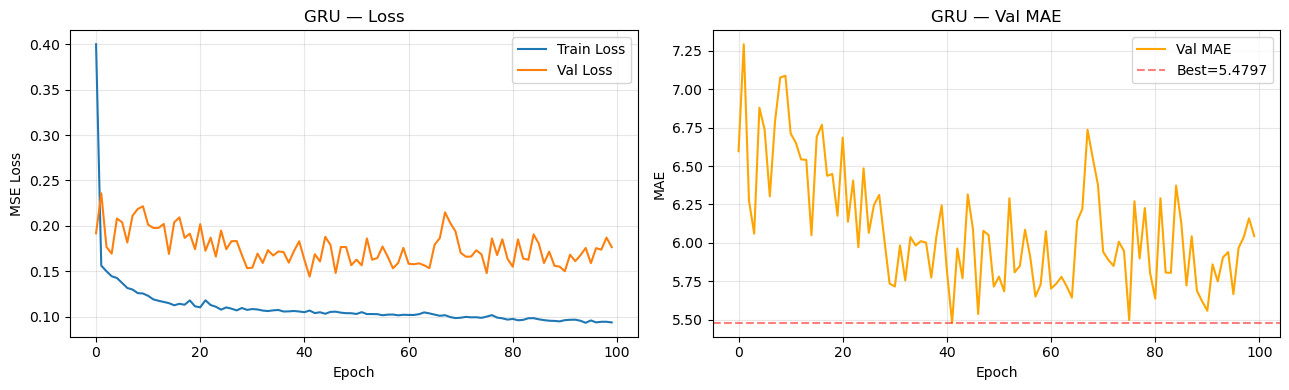

In [55]:
# 7. Визуализации и сохранение артефактов
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"],   label="Val Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
axes[0].set_title("GRU — Loss"); axes[0].legend(); axes[0].grid(True, alpha=.3)

axes[1].plot(history["val_mae"], color="orange", label="Val MAE")
axes[1].axhline(best_val_mae, color="red", ls="--", alpha=.5, label=f"Best={best_val_mae:.4f}")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE")
axes[1].set_title("GRU — Val MAE"); axes[1].legend(); axes[1].grid(True, alpha=.3)

plt.tight_layout()
plt.savefig("artifacts/figures/gru_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

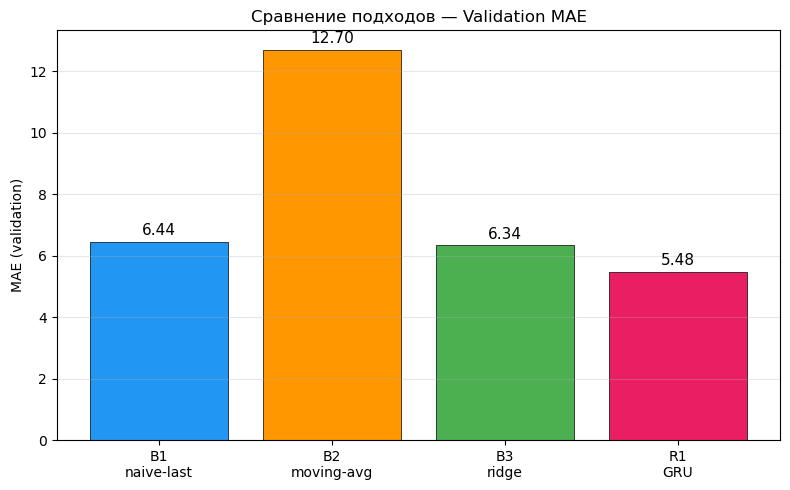

In [58]:
fig, ax = plt.subplots(figsize=(8, 5))
labels = ["B1\nnaive-last", "B2\nmoving-avg", "B3\nridge", "R1\nGRU"]
vals   = [m_b1_val["MAE"], m_b2_val["MAE"], m_b3_val["MAE"], m_r1_val["MAE"]]
colors = ["#2196F3", "#FF9800", "#4CAF50", "#E91E63"]
bars   = ax.bar(labels, vals, color=colors, edgecolor="black", lw=.5)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + max(vals)*0.01,
            f"{v:.2f}", ha="center", va="bottom", fontsize=11)
ax.set_ylabel("MAE (validation)")
ax.set_title("Сравнение подходов — Validation MAE")
ax.grid(axis="y", alpha=.3)
plt.tight_layout()
plt.savefig("artifacts/figures/baselines_compare.png", dpi=150, bbox_inches="tight")
plt.show()

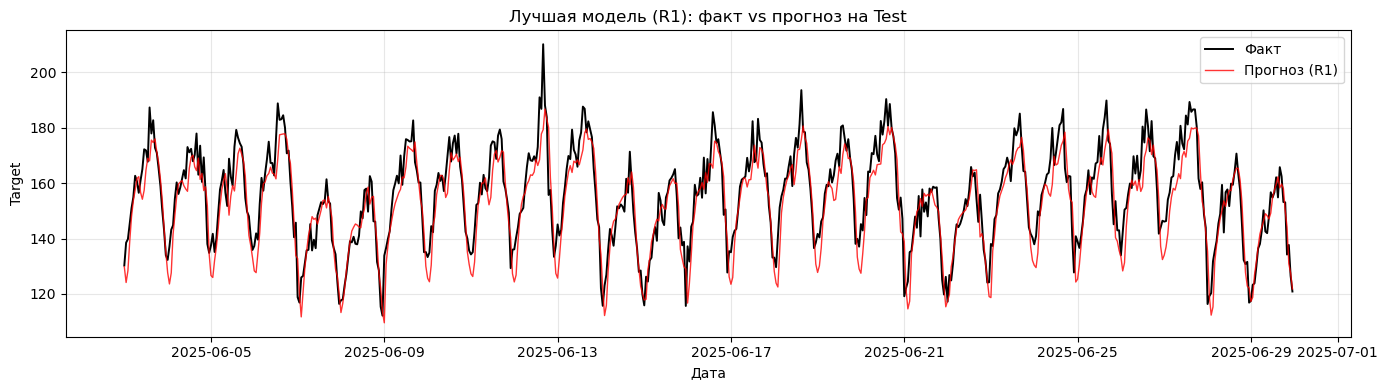

In [59]:
best_preds_map = {"B1": test_pred_b1, "B2": test_pred_b2,
                  "B3": test_pred_b3, "R1": test_pred_r1}
best_true_map  = {"B1": test_true_bl, "B2": test_true_bl,
                  "B3": test_true_bl, "R1": test_true_r1}
best_dates_map = {
    "B1": test_feat["date"].values, "B2": test_feat["date"].values,
    "B3": test_feat["date"].values,
    "R1": df["date"].iloc[val_end:val_end + len(test_pred_r1)].values,
}

bp = best_preds_map[best_id]
bt = best_true_map[best_id]
bd = best_dates_map[best_id]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(bd, bt, label="Факт",   color="black", lw=1.4)
ax.plot(bd, bp, label=f"Прогноз ({best_id})", color="red", lw=1, alpha=.8)
ax.set_title(f"Лучшая модель ({best_id}): факт vs прогноз на Test")
ax.set_xlabel("Дата"); ax.set_ylabel("Target")
ax.legend(); ax.grid(True, alpha=.3)
plt.tight_layout()
plt.savefig("artifacts/figures/best_forecast_test.png", dpi=150, bbox_inches="tight")
plt.show()

In [60]:
# runs.csv
def row(eid, model_sum, feat_sum, scaler, opt, lr, ep,
        vm, vt_m, note, ws=""):
    return {
        "experiment_id": eid, "task": "forecasting",
        "dataset": "S12-hw-dataset.csv", "seed": SEED,
        "split_summary": SPLIT_SUMMARY,
        "window_size": ws, "horizon": HORIZON,
        "model_summary": model_sum, "features_summary": feat_sum,
        "scaler": scaler, "optimizer": opt, "lr": lr,
        "epochs_trained": ep,
        "best_val_mae":  round(vm["MAE"],  4),
        "best_val_rmse": round(vm["RMSE"], 4),
        "best_val_mape": round(vm["MAPE"], 2),
        "test_mae":  round(vt_m["MAE"],  4) if eid == best_id else "",
        "test_rmse": round(vt_m["RMSE"], 4) if eid == best_id else "",
        "test_mape": round(vt_m["MAPE"], 2) if eid == best_id else "",
        "notes": note,
    }

runs = pd.DataFrame([
    row("B1", "naive-last (lag_1)", "lag_1", "", "", "", "",
        m_b1_val, m_b1_test, "pred = prev value"),
    row("B2", "moving-average-7", "rolling_mean_7", "", "", "", "",
        m_b2_val, m_b2_test, "pred = MA(7)"),
    row("B3", "Ridge(alpha=1.0)", ", ".join(FEATURE_COLS),
        "StandardScaler", "", "", "",
        m_b3_val, m_b3_test, "Ridge on lag+rolling+calendar"),
    row("R1", f"GRU(h={HIDDEN_SIZE},L={NUM_LAYERS})", "raw target (scaled)",
        "StandardScaler", "Adam", LR, best_epoch,
        m_r1_val, m_r1_test, f"best_epoch={best_epoch}", ws=WINDOW_SIZE),
])
runs.to_csv("artifacts/runs.csv", index=False)
print("✔ Saved artifacts/runs.csv")
display(runs)

# best_gru_config.json 
cfg = {
    "model": "GRU", "input_size": 1, "hidden_size": HIDDEN_SIZE,
    "num_layers": NUM_LAYERS, "window_size": WINDOW_SIZE,
    "horizon": HORIZON, "batch_size": BATCH_SIZE,
    "learning_rate": LR, "optimizer": "Adam",
    "criterion": "MSELoss", "epochs_total": EPOCHS,
    "best_epoch": best_epoch, "seed": SEED,
    "scaler": "StandardScaler", "device": str(DEVICE),
}
with open("artifacts/best_gru_config.json", "w") as f:
    json.dump(cfg, f, indent=2)
print("Saved best_gru_config.json")

✔ Saved artifacts/runs.csv


,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,67,"train=3024,val=648,test=648",,1,naive-last (lag_1),lag_1,,,,,6.4448,8.2010,4.40,,,,pred = prev value
1,B2,forecasting,S12-hw-dataset.csv,67,"train=3024,val=648,test=648",,1,moving-average-7,rolling_mean_7,,,,,12.7020,15.2176,8.82,,,,pred = MA(7)
2,B3,forecasting,S12-hw-dataset.csv,67,"train=3024,val=648,test=648",,1,Ridge(alpha=1.0),"lag_1, lag_7, lag_14, rolling_mean_7, rolling_...",StandardScaler,,,,6.3351,7.9237,4.24,,,,Ridge on lag+rolling+calendar
3,R1,forecasting,S12-hw-dataset.csv,67,"train=3024,val=648,test=648",14,1,"GRU(h=64,L=1)",raw target (scaled),StandardScaler,Adam,0.001,42,5.4797,7.0464,3.69,6.2267,7.9421,4.03,best_epoch=42


Saved best_gru_config.json


## 8. Обсуждение возможных утечек данных

1. **Лаговые и rolling-признаки** построены с `shift(1)` / `shift(k)`,
   поэтому каждый признак использует только **прошлые** значения target.
   Текущее значение target в признаки не попадает.

2. **Scaler** (`StandardScaler`) для признаков и для target (в GRU)
   обучен **только на train**; `transform` применяется к val и test —
   утечки через статистики нет.

3. **Random split** мог бы вызвать утечку: lag-признаки для
   тренировочной точки могли бы содержать значения из «будущего» (из
   test), что искусственно завысило бы метрики.

4. **Rolling-статистики** при неправильном окне (без `shift`) включили бы
   текущее значение — это ещё один типичный источник утечки; здесь он
   исключён.